# 04 — Pseudo-Labeling Pipeline

This notebook uses the CBAM-trained model to auto-generate labels for unlabeled aerial images, then retrains on the expanded dataset. Pseudo-labeling reduces manual annotation burden for drone datasets while expanding training data.

**Pipeline:**
1. Take 100 unlabeled images from the validation set
2. Run inference with confidence threshold 0.5
3. Save detections as pseudo-labels (reject low-confidence images)
4. Retrain on the expanded dataset
5. Measure mAP improvement over baseline and CBAM-only

## Install Dependencies and Mount Drive

In [1]:
!pip install ultralytics -q

from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

candidate_paths = [
    Path('/content/drive/MyDrive/uav-small-object-detector'),
    Path('/content/drive/MyDrive/uav-small-object-detector/UAV_small_obj_detector'),
    Path('/content/drive/MyDrive/UAV_small_obj_detector'),
]

project_root = next((path for path in candidate_paths if path.exists()), None)
if project_root is None:
    raise FileNotFoundError(
        'Could not find the project folder in Google Drive. '
        'Check MyDrive/uav-small-object-detector and MyDrive/UAV_small_obj_detector.'
    )

os.chdir(project_root)
print(f'Working directory: {project_root}')
!pwd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.0 MB/s eta 0:00:00
Mounted at /content/drive
Working directory: /content/drive/MyDrive/UAV_small_obj_detector
/content/drive/MyDrive/UAV_small_obj_detector


## Restore VisDrone Dataset If Needed

In [2]:
import shutil
from PIL import Image
from ultralytics.utils.downloads import download

dataset_root = Path('/content/VisDrone')

def visdrone2yolo(root, split, source_name):
    source_dir = root / source_name
    images_dir = root / 'images' / split
    labels_dir = root / 'labels' / split
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    for img in (source_dir / 'images').glob('*.jpg'):
        shutil.move(str(img), str(images_dir / img.name))

    for ann in (source_dir / 'annotations').glob('*.txt'):
        img_path = images_dir / ann.with_suffix('.jpg').name
        img_w, img_h = Image.open(img_path).size
        dw, dh = 1.0 / img_w, 1.0 / img_h
        lines = []

        with open(ann, encoding='utf-8') as f:
            rows = [x.split(',') for x in f.read().strip().splitlines()]

        for row in rows:
            if row[4] != '0':
                x, y, w, h = map(int, row[:4])
                cls = int(row[5]) - 1
                x_center = (x + w / 2) * dw
                y_center = (y + h / 2) * dh
                w_norm = w * dw
                h_norm = h * dh
                lines.append(f'{cls} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n')

        with open(labels_dir / ann.name, 'w', encoding='utf-8') as out:
            out.writelines(lines)

if not (dataset_root / 'images' / 'val').exists():
    urls = [
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip',
        'https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-test-dev.zip',
    ]
    download(urls, dir=dataset_root, threads=4)

    for folder, split in {
        'VisDrone2019-DET-train': 'train',
        'VisDrone2019-DET-val': 'val',
        'VisDrone2019-DET-test-dev': 'test',
    }.items():
        visdrone2yolo(dataset_root, split, folder)
        shutil.rmtree(dataset_root / folder)

print(f"Train images: {len(os.listdir('/content/VisDrone/images/train'))}")
print(f"Val images: {len(os.listdir('/content/VisDrone/images/val'))}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Unzipping /content/VisDrone/VisDrone2019-DET-val.zip to /content/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 2.0Kfiles/s 0.5s
Unzipping /content/VisDrone/VisDrone2019-DET-test-dev.zip to /content/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 1.4Kfiles/s 2.2s
Unzipping /content/VisDrone/VisDrone2019-DET-train.zip to /content/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 1.7Kfiles/s 7.5s
Train images: 6471
Val images: 548


## Setup: Copy Last 100 Val Images as Unlabeled

In [3]:
import shutil

val_dir = '/content/VisDrone/images/val'
unlabeled_dir = '/content/unlabeled_100'
if os.path.exists(unlabeled_dir):
    shutil.rmtree(unlabeled_dir)
os.makedirs(unlabeled_dir, exist_ok=True)

val_imgs = sorted(os.listdir(val_dir))
pseudo_src_imgs = val_imgs[-100:]  # last 100 val images as unlabeled
for img in pseudo_src_imgs:
    shutil.copy(os.path.join(val_dir, img), unlabeled_dir)

print(f"Copied {len(pseudo_src_imgs)} unlabeled images.")

Copied 100 unlabeled images.


## Generate Pseudo-Labels

In [3]:
import os
import sys
import shutil
from pathlib import Path

# Find the real project root that contains src/pseudo_label.py
candidate_roots = [
    Path('/content/drive/MyDrive/UAV_small_obj_detector'),
    Path('/content/drive/MyDrive/uav-small-object-detector'),
    Path('/content/drive/MyDrive/uav-small-object-detector/UAV_small_obj_detector'),
]

project_root = next(
    (p for p in candidate_roots if (p / 'src' / 'pseudo_label.py').exists()),
    None
)

if project_root is None:
    raise FileNotFoundError("Could not find src/pseudo_label.py in Google Drive project folder.")

os.chdir(project_root)
sys.path.insert(0, str(project_root))

from src.pseudo_label import generate_pseudo_labels

# Recreate unlabeled image pool
val_dir = '/content/VisDrone/images/val'
unlabeled_dir = '/content/unlabeled_100'

if os.path.exists(unlabeled_dir):
    shutil.rmtree(unlabeled_dir)
os.makedirs(unlabeled_dir, exist_ok=True)

val_imgs = sorted(os.listdir(val_dir))
pseudo_src_imgs = val_imgs[-100:]
for img in pseudo_src_imgs:
    shutil.copy(os.path.join(val_dir, img), unlabeled_dir)

print(f"Copied {len(pseudo_src_imgs)} unlabeled images.")

# Find latest CBAM weights
weight_candidates = sorted(project_root.glob('runs/detect/cbam_visdrone*/weights/best.pt'))
if not weight_candidates:
    raise FileNotFoundError(
        'Could not find any CBAM weights. Expected a path like '
        'runs/detect/cbam_visdrone*/weights/best.pt'
    )

cbam_weight = str(weight_candidates[-1])

pseudo_label_dir = '/content/pseudo_labels'
if os.path.exists(pseudo_label_dir):
    shutil.rmtree(pseudo_label_dir)

accepted, rejected = generate_pseudo_labels(
    model_path=cbam_weight,
    unlabeled_dir=unlabeled_dir,
    output_dir=pseudo_label_dir,
    conf=0.5
)

print(f"Using project root: {project_root}")
print(f"Using CBAM weights: {cbam_weight}")
print(f"Accepted: {accepted}")
print(f"Rejected: {rejected}")

total = accepted + rejected
acceptance_rate = (accepted / total * 100.0) if total else 0.0
print(f"Acceptance rate: {acceptance_rate:.1f}% ({accepted}/{total} images)")


Copied 100 unlabeled images.
Accepted: 100 | Rejected (low conf): 0
Pseudo-label acceptance rate: 100.0%
Using project root: /content/drive/MyDrive/UAV_small_obj_detector
Using CBAM weights: /content/drive/MyDrive/UAV_small_obj_detector/runs/detect/cbam_visdrone2/weights/best.pt
Accepted: 100
Rejected: 0
Acceptance rate: 100.0% (100/100 images)


## Create Expanded YAML for Retraining

In [4]:
%%writefile visdrone_expanded.yaml
path: /content/VisDrone_expanded
train: images/train
val: images/val
nc: 10
names: ['pedestrian','people','bicycle','car','van','truck',
        'tricycle','awning-tricycle','bus','motor']

Writing visdrone_expanded.yaml


## Merge Original Training Data with Pseudo-Labels

In [5]:
import shutil

# Create a clean expanded dataset directory each run.
expanded_base = '/content/VisDrone_expanded'
if os.path.exists(expanded_base):
    shutil.rmtree(expanded_base)
expanded_train = os.path.join(expanded_base, 'images/train')
expanded_labels = os.path.join(expanded_base, 'labels/train')
os.makedirs(expanded_train, exist_ok=True)
os.makedirs(expanded_labels, exist_ok=True)

# Copy original training images and labels
orig_img_dir = '/content/VisDrone/images/train'
orig_label_dir = '/content/VisDrone/labels/train'
for img in os.listdir(orig_img_dir):
    shutil.copy(os.path.join(orig_img_dir, img), expanded_train)
for lbl in os.listdir(orig_label_dir):
    shutil.copy(os.path.join(orig_label_dir, lbl), expanded_labels)

# Copy pseudo-labeled images and labels
for img in os.listdir(unlabeled_dir):
    shutil.copy(os.path.join(unlabeled_dir, img), expanded_train)
for lbl in os.listdir(pseudo_label_dir):
    shutil.copy(os.path.join(pseudo_label_dir, lbl), expanded_labels)

# Copy val set (unchanged)
expanded_val = os.path.join(expanded_base, 'images/val')
expanded_val_labels = os.path.join(expanded_base, 'labels/val')
os.makedirs(expanded_val, exist_ok=True)
os.makedirs(expanded_val_labels, exist_ok=True)
val_img_dir = '/content/VisDrone/images/val'
val_label_dir = '/content/VisDrone/labels/val'
for img in os.listdir(val_img_dir):
    shutil.copy(os.path.join(val_img_dir, img), expanded_val)
for lbl in os.listdir(val_label_dir):
    shutil.copy(os.path.join(val_label_dir, lbl), expanded_val_labels)

print(f"Expanded train: {len(os.listdir(expanded_train))} images")
print(f"Expanded labels: {len(os.listdir(expanded_labels))} label files")
print(f"Validation set copied: {len(os.listdir(expanded_val))} images")

Expanded train: 6571 images
Expanded labels: 6571 label files
Validation set copied: 548 images


## Retrain on Expanded Dataset

In [6]:
from ultralytics import YOLO

model_expanded = YOLO(cbam_weight)
train_results = model_expanded.train(
    data='visdrone_expanded.yaml',
    epochs=10,
    name='pseudo_label_visdrone',
    save_period=5
)
print('Retraining complete.')

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone_expanded.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/UAV_small_obj_detector/runs/detect/cbam_visdrone2/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pseudo_label_visdrone, nbs=64, nms=False, o

## Evaluate Pseudo-Label Model

In [7]:
pseudo_weight_candidates = sorted(project_root.glob('runs/detect/pseudo_label_visdrone*/weights/best.pt'))
if not pseudo_weight_candidates:
    raise FileNotFoundError(
        'Could not find pseudo-label weights. Expected a path like '
        "runs/detect/pseudo_label_visdrone*/weights/best.pt"
    )

pseudo_best = pseudo_weight_candidates[-1]
best_pseudo_model = YOLO(str(pseudo_best))
metrics_pseudo = best_pseudo_model.val(data='visdrone_expanded.yaml')
pseudo_map50 = float(metrics_pseudo.box.map50)
pseudo_map = float(metrics_pseudo.box.map)
pseudo_precision = float(metrics_pseudo.box.mp)
pseudo_recall = float(metrics_pseudo.box.mr)
print(f"Pseudo-label best weights: {pseudo_best}")
print(f"Pseudo-label mAP@50:    {pseudo_map50:.4f}")
print(f"Pseudo-label mAP@50-95: {pseudo_map:.4f}")
print(f"Pseudo-label precision: {pseudo_precision:.4f}")
print(f"Pseudo-label recall:    {pseudo_recall:.4f}")

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2912.5±1141.6 MB/s, size: 153.1 KB)
val: Scanning /content/VisDrone_expanded/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 176.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.2it/s 10.9s
                   all        548      38759      0.419      0.312      0.307      0.176
            pedestrian        520       8844      0.372      0.357      0.323      0.133
                people        482       5125      0.432       0.25      0.255     0.0903
               bicycle        364       1287      0.218     0.0917     0.0657     0.0237
                   car        515      14064      0.565      0.749      0.732      0.492
                   van        421    

## Save All Metrics to JSON

In [16]:
import json

metrics_path = Path('results/metrics.json')
if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        all_metrics = json.load(f)
else:
    all_metrics = {}

all_metrics.setdefault('baseline', {})
all_metrics.setdefault('cbam', {})

all_metrics["pseudo_label"] = {
    "mAP50": pseudo_map50,
    "mAP50-95": pseudo_map,
    "precision": pseudo_precision,
    "recall": pseudo_recall,
    "accepted": accepted,
    "rejected": rejected,
    "acceptance_rate": acceptance_rate,
    "weights": str(pseudo_best)
}

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(all_metrics, f, indent=2)

print("All metrics saved.")
print(json.dumps(all_metrics, indent=2))

All metrics saved.
{
  "baseline": {
    "mAP50": 0.29373669317784457,
    "mAP50-95": 0.1662671086264691,
    "precision": 0.39159907325051424,
    "recall": 0.30258304542539205
  },
  "cbam": {
    "mAP50": 0.30206881342972747,
    "mAP50-95": 0.17270067683582924,
    "precision": 0.414643359389183,
    "recall": 0.3024832252138724
  },
  "pseudo_label": {
    "mAP50": 0.3072394253534811,
    "mAP50-95": 0.1755445358297251,
    "precision": 0.4185700011011811,
    "recall": 0.3119329290737634,
    "accepted": 100,
    "rejected": 0,
    "acceptance_rate": 100.0,
    "weights": "/content/drive/MyDrive/UAV_small_obj_detector/runs/detect/pseudo_label_visdrone/weights/best.pt"
  }
}


## Generate Full Progression Chart

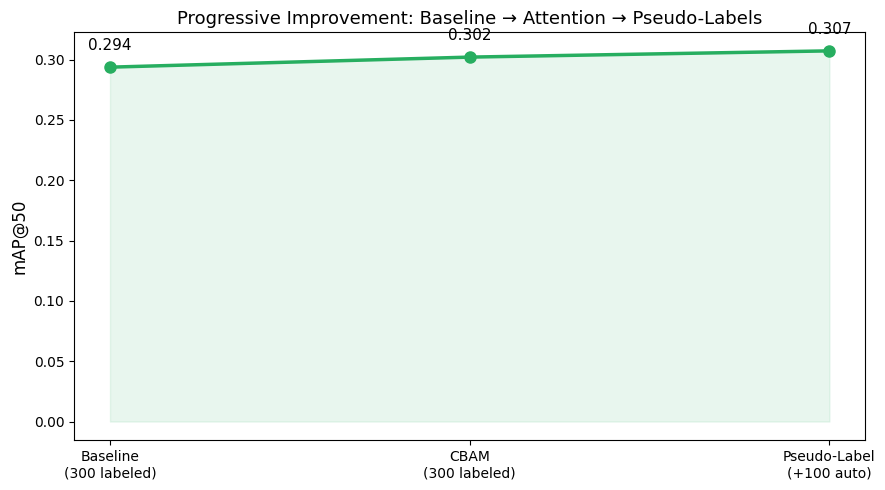

Progression chart saved to results/full_progression.png


In [9]:
import matplotlib.pyplot as plt

baseline_map50 = all_metrics['baseline'].get('mAP50', 0.29373669317784457)
cbam_map50 = all_metrics['cbam'].get('mAP50', 0.30206881342972747)

stages = ['Baseline\n(300 labeled)', 'CBAM\n(300 labeled)', 'Pseudo-Label\n(+100 auto)']
scores = [baseline_map50, cbam_map50, pseudo_map50]

plt.figure(figsize=(9, 5))
plt.plot(stages, scores, marker='o', color='#27ae60', linewidth=2.5, markersize=8)
plt.fill_between(range(len(stages)), scores, alpha=0.1, color='#27ae60')
plt.ylabel('mAP@50', fontsize=12)
plt.title('Progressive Improvement: Baseline → Attention → Pseudo-Labels',
          fontsize=13)

# Add value labels on each point
for i, (stage, score) in enumerate(zip(stages, scores)):
    plt.annotate(f'{score:.3f}', (i, score), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('results/full_progression.png', dpi=150)
plt.show()

print("Progression chart saved to results/full_progression.png")